---
Phase 4-CV-3: 遷移學習 — 站在巨人的肩膀上
---

自己從零訓練 CNN？你需要：
  - 百萬張圖片
  - 幾十張 GPU
  - 訓練好幾天

遷移學習：拿別人訓練好的模型來用！
  - ImageNet 上的 pretrained model 已經學會了通用的視覺特徵
  - 淺層學到邊緣、紋理（通用的）
  - 深層學到物體部件、特定特徵（任務相關的）

本檔涵蓋：
  1. 遷移學習的概念
  2. Feature Extraction（凍結 backbone）
  3. Fine-Tuning（解凍部分層）
  4. 實作：用 pretrained ResNet 做分類

In [1]:
%matplotlib inline
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt

/home/acer/.local/lib/python3.12/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

## 1. 遷移學習概念

In [3]:
print("=" * 60)
print("1. 遷移學習 — 為什麼有效？")
print("=" * 60)

print("""
CNN 的層次特徵：

  淺層（Layer 1-2）：邊緣、顏色、紋理
  ↓  ← 通用的！幾乎所有圖片任務都用得到
  中層（Layer 3-5）：角、圖案、部件
  ↓  ← 部分通用
  深層（Last layers）：物體、場景
  ↓  ← 任務相關的
  FC 層：分類決策

遷移學習的策略：

  策略 1: Feature Extraction（特徵提取）
  ┌──────────────────────────────────┐
  │  Pretrained CNN (凍結所有參數)     │ ← 不更新
  │  → 提取特徵向量                    │
  │  → 新的 FC 層                     │ ← 只訓練這裡
  └──────────────────────────────────┘
  適合：資料少、任務和 ImageNet 類似

  策略 2: Fine-Tuning（微調）
  ┌──────────────────────────────────┐
  │  Pretrained CNN                   │
  │  ├─ 淺層（凍結）                   │ ← 不更新
  │  ├─ 深層（解凍，小 LR 更新）        │ ← 慢慢更新
  │  └─ 新的 FC 層（正常 LR）          │ ← 正常更新
  └──────────────────────────────────┘
  適合：資料多、任務和 ImageNet 有差異

  策略 3: Full Fine-Tuning（全部解凍）
  適合：資料非常多、任務差異大
""")

1. 遷移學習 — 為什麼有效？

CNN 的層次特徵：

  淺層（Layer 1-2）：邊緣、顏色、紋理
  ↓  ← 通用的！幾乎所有圖片任務都用得到
  中層（Layer 3-5）：角、圖案、部件
  ↓  ← 部分通用
  深層（Last layers）：物體、場景
  ↓  ← 任務相關的
  FC 層：分類決策

遷移學習的策略：

  策略 1: Feature Extraction（特徵提取）
  ┌──────────────────────────────────┐
  │  Pretrained CNN (凍結所有參數)     │ ← 不更新
  │  → 提取特徵向量                    │
  │  → 新的 FC 層                     │ ← 只訓練這裡
  └──────────────────────────────────┘
  適合：資料少、任務和 ImageNet 類似

  策略 2: Fine-Tuning（微調）
  ┌──────────────────────────────────┐
  │  Pretrained CNN                   │
  │  ├─ 淺層（凍結）                   │ ← 不更新
  │  ├─ 深層（解凍，小 LR 更新）        │ ← 慢慢更新
  │  └─ 新的 FC 層（正常 LR）          │ ← 正常更新
  └──────────────────────────────────┘
  適合：資料多、任務和 ImageNet 有差異

  策略 3: Full Fine-Tuning（全部解凍）
  適合：資料非常多、任務差異大



## 2. 載入 Pretrained 模型

In [4]:
print("=" * 60)
print("2. 載入 Pretrained 模型")
print("=" * 60)

print("""
PyTorch 提供了很多 pretrained 模型：
  torchvision.models.resnet18(weights='IMAGENET1K_V1')
  torchvision.models.resnet50(weights='IMAGENET1K_V2')
  torchvision.models.efficientnet_b0(weights='IMAGENET1K_V1')

模型已在 ImageNet（1000 類、128 萬張圖）上訓練好。
""")

# 為了不依賴 torchvision 的 pretrained weights（下載很大），
# 我們用自訓練的方式模擬遷移學習的概念

# 先訓練一個「pretrained」模型（在一個任務上）
# 然後遷移到另一個任務

from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, TensorDataset

digits = load_digits()
X = digits.data.reshape(-1, 1, 8, 8).astype(np.float32) / 16.0
y = digits.target.astype(np.int64)

# 任務 A: 辨識偶數 vs 奇數（binary）
y_binary = (y % 2).astype(np.int64)

# 任務 B: 辨識 0-4 vs 5-9（binary）
y_half = (y >= 5).astype(np.int64)

X_tr_a, X_te_a, y_tr_a, y_te_a = train_test_split(X, y_binary, test_size=0.2, random_state=42)
X_tr_b, X_te_b, y_tr_b, y_te_b = train_test_split(X, y_half, test_size=0.2, random_state=42)


class FeatureExtractor(nn.Module):
    """特徵提取 backbone"""
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 16, 3, padding=1), nn.BatchNorm2d(16), nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(16, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.AdaptiveAvgPool2d(1),
        )

    def forward(self, x):
        return self.features(x).view(x.size(0), -1)  # (B, 64)


class FullModel(nn.Module):
    """完整模型 = backbone + classifier"""
    def __init__(self, num_classes=2):
        super().__init__()
        self.backbone = FeatureExtractor()
        self.classifier = nn.Linear(64, num_classes)

    def forward(self, x):
        features = self.backbone(x)
        return self.classifier(features)

2. 載入 Pretrained 模型

PyTorch 提供了很多 pretrained 模型：
  torchvision.models.resnet18(weights='IMAGENET1K_V1')
  torchvision.models.resnet50(weights='IMAGENET1K_V2')
  torchvision.models.efficientnet_b0(weights='IMAGENET1K_V1')

模型已在 ImageNet（1000 類、128 萬張圖）上訓練好。



## 3. Feature Extraction 示範

In [5]:
print("\n" + "=" * 60)
print("3. Feature Extraction — 凍結 backbone")
print("=" * 60)


def train_model(model, X_tr, y_tr, X_te, y_te, epochs=30, lr=0.001):
    model = model.to(device)
    optimizer = torch.optim.Adam(
        filter(lambda p: p.requires_grad, model.parameters()), lr=lr
    )
    criterion = nn.CrossEntropyLoss()
    loader = DataLoader(
        TensorDataset(torch.tensor(X_tr), torch.tensor(y_tr)),
        batch_size=32, shuffle=True
    )

    for epoch in range(epochs):
        model.train()
        for bx, by in loader:
            bx, by = bx.to(device), by.to(device)
            loss = criterion(model(bx), by)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

    model.eval()
    with torch.no_grad():
        X_te_t = torch.tensor(X_te).to(device)
        y_te_t = torch.tensor(y_te).to(device)
        acc = (model(X_te_t).argmax(1) == y_te_t).float().mean().item()
    return acc


# Step 1: 在任務 A 上訓練「pretrained」模型
print("\nStep 1: 在任務 A（奇偶辨識）上訓練模型...")
torch.manual_seed(42)
pretrained = FullModel(num_classes=2)
acc_a = train_model(pretrained, X_tr_a, y_tr_a, X_te_a, y_te_a, epochs=40)
print(f"  任務 A 準確率: {acc_a:.2%}")

# Step 2: 遷移到任務 B
print("\nStep 2: 遷移到任務 B（0-4 vs 5-9）")

# 方法 1: 從零訓練（baseline）
print("\n  方法 1: 從零訓練（no transfer）")
torch.manual_seed(42)
scratch_model = FullModel(num_classes=2)
acc_scratch = train_model(scratch_model, X_tr_b, y_tr_b, X_te_b, y_te_b, epochs=15)
print(f"    準確率 (15 epochs): {acc_scratch:.2%}")

# 方法 2: Feature Extraction（凍結 backbone）
print("\n  方法 2: Feature Extraction（凍結 backbone）")
transfer_model = FullModel(num_classes=2)
# 載入 pretrained 的 backbone 權重
transfer_model.backbone.load_state_dict(pretrained.backbone.state_dict())
# 凍結 backbone
for param in transfer_model.backbone.parameters():
    param.requires_grad = False

trainable = sum(p.numel() for p in transfer_model.parameters() if p.requires_grad)
total = sum(p.numel() for p in transfer_model.parameters())
print(f"    可訓練參數: {trainable:,} / {total:,} ({trainable/total:.1%})")

acc_feature = train_model(transfer_model, X_tr_b, y_tr_b, X_te_b, y_te_b, epochs=15)
print(f"    準確率 (15 epochs): {acc_feature:.2%}")

# 方法 3: Fine-Tuning（解凍後面幾層）
print("\n  方法 3: Fine-Tuning（解凍深層）")
finetune_model = FullModel(num_classes=2)
finetune_model.backbone.load_state_dict(pretrained.backbone.state_dict())

# 凍結淺層，解凍深層
for name, param in finetune_model.backbone.named_parameters():
    if 'features.0' in name or 'features.1' in name or 'features.2' in name or 'features.3' in name:
        param.requires_grad = False  # 凍結前兩個 conv block
    # 深層保持解凍

trainable = sum(p.numel() for p in finetune_model.parameters() if p.requires_grad)
print(f"    可訓練參數: {trainable:,} / {total:,} ({trainable/total:.1%})")

acc_finetune = train_model(finetune_model, X_tr_b, y_tr_b, X_te_b, y_te_b, epochs=15, lr=0.0005)
print(f"    準確率 (15 epochs): {acc_finetune:.2%}")


3. Feature Extraction — 凍結 backbone

Step 1: 在任務 A（奇偶辨識）上訓練模型...


  任務 A 準確率: 99.72%

Step 2: 遷移到任務 B（0-4 vs 5-9）

  方法 1: 從零訓練（no transfer）


    準確率 (15 epochs): 99.44%

  方法 2: Feature Extraction（凍結 backbone）
    可訓練參數: 130 / 23,650 (0.5%)


    準確率 (15 epochs): 74.44%

  方法 3: Fine-Tuning（解凍深層）
    可訓練參數: 23,458 / 23,650 (99.2%)


    準確率 (15 epochs): 99.44%


## 4. 遷移學習的實務技巧

In [6]:
print("\n" + "=" * 60)
print("4. 遷移學習實務技巧")
print("=" * 60)

print("""
使用 torchvision pretrained model 的標準流程：

  import torchvision.models as models

  # 1. 載入 pretrained model
  model = models.resnet18(weights='IMAGENET1K_V1')

  # 2. 凍結所有參數
  for param in model.parameters():
      param.requires_grad = False

  # 3. 替換最後一層（ResNet 的 fc 層原本輸出 1000 類）
  model.fc = nn.Linear(model.fc.in_features, num_classes)
  # 新的 fc 層預設 requires_grad=True

  # 4. 只優化新的 fc 層
  optimizer = torch.optim.Adam(model.fc.parameters(), lr=0.001)

  # 5. (可選) Fine-tune: 解凍最後幾層
  for param in model.layer4.parameters():
      param.requires_grad = True

  # 6. 用不同學習率
  optimizer = torch.optim.Adam([
      {'params': model.layer4.parameters(), 'lr': 1e-4},
      {'params': model.fc.parameters(), 'lr': 1e-3},
  ])
""")

# 展示凍結/解凍的操作
print("--- 凍結/解凍操作示範 ---")
model = FullModel()

# 凍結所有
for param in model.parameters():
    param.requires_grad = False
frozen = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"全部凍結: {frozen} 個可訓練參數")

# 只解凍 classifier
for param in model.classifier.parameters():
    param.requires_grad = True
partial = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"只解凍 classifier: {partial} 個可訓練參數")

# 全部解凍
for param in model.parameters():
    param.requires_grad = True
all_p = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"全部解凍: {all_p} 個可訓練參數")


4. 遷移學習實務技巧

使用 torchvision pretrained model 的標準流程：

  import torchvision.models as models

  # 1. 載入 pretrained model
  model = models.resnet18(weights='IMAGENET1K_V1')

  # 2. 凍結所有參數
  for param in model.parameters():
      param.requires_grad = False

  # 3. 替換最後一層（ResNet 的 fc 層原本輸出 1000 類）
  model.fc = nn.Linear(model.fc.in_features, num_classes)
  # 新的 fc 層預設 requires_grad=True

  # 4. 只優化新的 fc 層
  optimizer = torch.optim.Adam(model.fc.parameters(), lr=0.001)

  # 5. (可選) Fine-tune: 解凍最後幾層
  for param in model.layer4.parameters():
      param.requires_grad = True

  # 6. 用不同學習率
  optimizer = torch.optim.Adam([
      {'params': model.layer4.parameters(), 'lr': 1e-4},
      {'params': model.fc.parameters(), 'lr': 1e-3},
  ])

--- 凍結/解凍操作示範 ---
全部凍結: 0 個可訓練參數
只解凍 classifier: 130 個可訓練參數
全部解凍: 23650 個可訓練參數


## 5. 資料預處理（配合 pretrained model）

In [7]:
print("\n" + "=" * 60)
print("5. 資料預處理 — ImageNet 標準化")
print("=" * 60)

print("""
Pretrained model 在 ImageNet 上訓練，使用特定的正規化：

  transform = transforms.Compose([
      transforms.Resize(256),                    # 調整大小
      transforms.CenterCrop(224),                # 裁剪到 224×224
      transforms.ToTensor(),                     # 轉成 tensor [0, 1]
      transforms.Normalize(
          mean=[0.485, 0.456, 0.406],            # ImageNet 的均值
          std=[0.229, 0.224, 0.225]              # ImageNet 的標準差
      ),
  ])

  你的資料也必須用同樣的正規化！
  因為模型是在這種分佈下訓練的。

  訓練時可以加 Data Augmentation：
  train_transform = transforms.Compose([
      transforms.RandomResizedCrop(224),          # 隨機裁剪
      transforms.RandomHorizontalFlip(),          # 隨機水平翻轉
      transforms.ColorJitter(0.2, 0.2, 0.2),     # 色彩抖動
      transforms.ToTensor(),
      transforms.Normalize([0.485, 0.456, 0.406],
                           [0.229, 0.224, 0.225]),
  ])
""")


5. 資料預處理 — ImageNet 標準化

Pretrained model 在 ImageNet 上訓練，使用特定的正規化：

  transform = transforms.Compose([
      transforms.Resize(256),                    # 調整大小
      transforms.CenterCrop(224),                # 裁剪到 224×224
      transforms.ToTensor(),                     # 轉成 tensor [0, 1]
      transforms.Normalize(
          mean=[0.485, 0.456, 0.406],            # ImageNet 的均值
          std=[0.229, 0.224, 0.225]              # ImageNet 的標準差
      ),
  ])

  你的資料也必須用同樣的正規化！
  因為模型是在這種分佈下訓練的。

  訓練時可以加 Data Augmentation：
  train_transform = transforms.Compose([
      transforms.RandomResizedCrop(224),          # 隨機裁剪
      transforms.RandomHorizontalFlip(),          # 隨機水平翻轉
      transforms.ColorJitter(0.2, 0.2, 0.2),     # 色彩抖動
      transforms.ToTensor(),
      transforms.Normalize([0.485, 0.456, 0.406],
                           [0.229, 0.224, 0.225]),
  ])



## 6. 結果比較圖

6. 結果比較


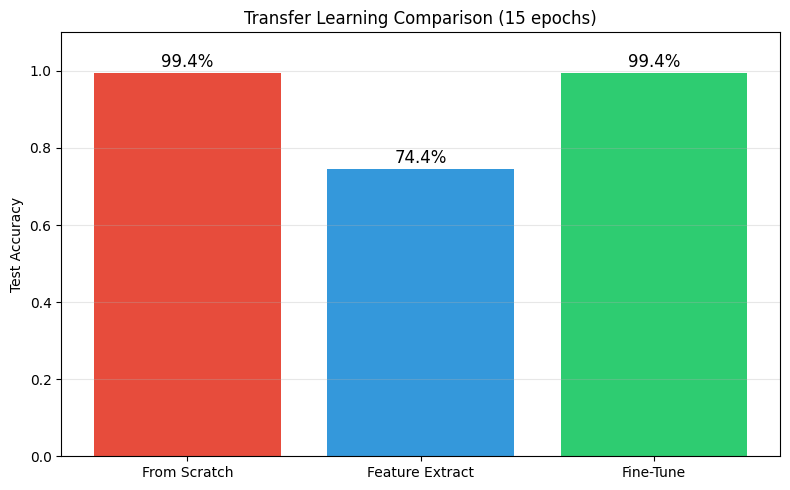

→ 圖表儲存至 cv/plots/03_transfer_learning.png


In [8]:
print("=" * 60)
print("6. 結果比較")
print("=" * 60)

methods = ['From Scratch', 'Feature Extract', 'Fine-Tune']
accs = [acc_scratch, acc_feature, acc_finetune]

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(methods, accs, color=['#e74c3c', '#3498db', '#2ecc71'])
for bar, acc in zip(bars, accs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{acc:.1%}', ha='center', va='bottom', fontsize=12)

ax.set_ylabel('Test Accuracy')
ax.set_title('Transfer Learning Comparison (15 epochs)')
ax.set_ylim(0, 1.1)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('phase-4-domains/cv/plots/03_transfer_learning.png', dpi=100)
plt.show()
print("→ 圖表儲存至 cv/plots/03_transfer_learning.png")

## 小結

In [9]:
print("\n" + "=" * 60)
print("小結")
print("=" * 60)
print("""
遷移學習重點：

  策略              資料量    和原任務相似度    做法
  ──────────────────────────────────────────────────────
  Feature Extract   少       高              凍結 backbone, 只訓練 FC
  Fine-Tune (部分)  中       中              解凍深層, 小 LR
  Fine-Tune (全部)  多       低              全部解凍, 小 LR

  實務建議：
  1. 先試 Feature Extraction（快、不容易過擬合）
  2. 如果不夠好，再 Fine-Tune
  3. Fine-Tune 時用小學習率（1e-4 ~ 1e-5）
  4. 資料預處理要和 pretrained model 一致
  5. 用不同學習率（backbone 小、head 大）

  常用 pretrained models：
  - ResNet-18/50: 經典、可靠
  - EfficientNet: 精度高、效率好
  - ViT (Vision Transformer): 最新、資料多時最強

Phase 4 CV 完成！
下一步：Phase 4 NLP — 自然語言處理
""")


小結

遷移學習重點：

  策略              資料量    和原任務相似度    做法
  ──────────────────────────────────────────────────────
  Feature Extract   少       高              凍結 backbone, 只訓練 FC
  Fine-Tune (部分)  中       中              解凍深層, 小 LR
  Fine-Tune (全部)  多       低              全部解凍, 小 LR

  實務建議：
  1. 先試 Feature Extraction（快、不容易過擬合）
  2. 如果不夠好，再 Fine-Tune
  3. Fine-Tune 時用小學習率（1e-4 ~ 1e-5）
  4. 資料預處理要和 pretrained model 一致
  5. 用不同學習率（backbone 小、head 大）

  常用 pretrained models：
  - ResNet-18/50: 經典、可靠
  - EfficientNet: 精度高、效率好
  - ViT (Vision Transformer): 最新、資料多時最強

Phase 4 CV 完成！
下一步：Phase 4 NLP — 自然語言處理

